# House Price Technical Assessment


**Submission includes:**
- Jupyter Notebook (`House_Price_Assessment.ipynb`)
- Cleaned Excel file (`House_Price_Cleaned.xlsx`)


## Overview & Instructions
This notebook shows the full workflow required in the assessment:

1. **Data Cleaning** – handle missing values, duplicates, and inconsistent years.
2. **Exploratory Data Analysis (EDA)** – distributions, correlations, and outliers.
3. **Feature Engineering** – encode categorical variables, create ratios, and normalize numeric features.
4. **Modeling** – train **Linear Regression** and **XGBoost**.
5. **Evaluation** – compare models using **RMSE** and **R²**.
6. **Hyperparameter Tuning & Feature Impact** – run tuning and discuss influential features.
7. **Reporting** – concise, mixed technical & non‑technical summary.


## Setup
### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin # For custom transformer
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# Set visualization style
sns.set_style("whitegrid")

## 1) Data Loading
Load the dataset and display a quick preview.

In [ ]:
# Uploading the file from my local computer
print("Please upload the 'House_Price.xlsx' file when prompted.")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
try:
    # Attempt to read as an Excel file
    df = pd.read_excel(file_name)
    print("Data loaded successfully.")
except Exception as e:
    print(f"Error loading data: {e}. Please ensure the file is in Excel format or change the read function.")

# Display the first few rows and information
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nDataset Information:")
df.info()

Please upload the 'House_Price.xlsx' file when prompted.


Saving House_Price.xlsx to House_Price (3).xlsx
Data loaded successfully.

First 5 rows of the dataset:
    Id  LotArea  OverallQual  YearBuilt  YearRemodAdd  TotalBsmtSF  GrLivArea  \
0   16   8311.0            6       2011          1967        719.0       1802   
1   10  14363.0            8       1965          1959        512.0       2994   
2  101  15383.0            3       2002          2010          NaN        927   
3  133      NaN            5       2020          1963        494.0       1514   
4   69  19216.0            7       1959          2000          NaN       3657   

   FullBath  BedroomAbvGr  GarageCars  ... HouseStyle  Condition Exterior  \
0         2           3.0           3  ...     1Story  Excellent   Cement   
1         1           5.0           3  ...     1Story       Fair    Vinyl   
2         1           3.0           1  ...     1Story       Fair     Wood   
3         3           NaN           3  ...     1Story       Good   Cement   
4         1           1.

# TASK 1
## 2) Data Cleaning
Goals:
- Remove duplicate rows
- Handle missing values (numeric → median, categorical → mode)
- Normalize inconsistent year values


## 2.1 Handle Duplicates
### We'll check for and remove duplicate rows based on all columns.

In [ ]:
print(f"Initial number of rows: {len(df)}")
# Check for duplicates based on all columns
duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows removed: {duplicates}")
print(f"New number of rows: {len(df)}")

Initial number of rows: 205
Number of duplicate rows removed: 5
New number of rows: 200


## 2.2 Handle Missing Values
### We'll identify columns with missing values and handle them appropriately.

In [ ]:
# Identify columns with missing values (NaN or empty strings represented as NaN by pandas)
print("\nMissing Values Count before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


# Impute numerical missing values with the median
numerical_cols_to_impute = ['LotArea', 'TotalBsmtSF', 'GrLivArea', 'BedroomAbvGr', 'GarageCars']
for col in numerical_cols_to_impute:
    df[col].fillna(df[col].median(), inplace=True)

# Impute categorical missing values with the mode
categorical_cols_to_impute = ['GarageType', 'Exterior', 'Heating']
for col in categorical_cols_to_impute:
    df[col].fillna(df[col].mode()[0], inplace=True)

# TotalRooms is a created/engineered feature in the uploaded data, but it has missing values. Impute with median.
df['TotalRooms'].fillna(df['TotalRooms'].median(), inplace=True)

# Final check for missing values
print("\nMissing Values Count after cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Missing Values Count before cleaning:
LotArea         14
TotalBsmtSF     14
BedroomAbvGr    14
GarageType      65
dtype: int64

Missing Values Count after cleaning:
Series([], dtype: int64)


## 2.3 Handle Inconsistent Years
### We need to check for logical inconsistencies in the year columns: YearBuilt, YearRemodAdd, and HouseAge.

In [ ]:
# Check for YearRemodAdd < YearBuilt
inconsistent_years = df[df['YearRemodAdd'] < df['YearBuilt']]
print(f"\nNumber of rows where YearRemodAdd < YearBuilt: {len(inconsistent_years)}")

# A more sophisticated approach might be needed, but for simplicity, we'll set the remod year to the built year
df.loc[df['YearRemodAdd'] < df['YearBuilt'], 'YearRemodAdd'] = df['YearBuilt']

# but we'll ensure it is non-negative and integer.
df['HouseAge'] = df['HouseAge'].abs().astype(int) # Ensure HouseAge is non-negative integer


Number of rows where YearRemodAdd < YearBuilt: 99


# Task 2  
## 3. Perform EDA
### Exploratory Data Analysis (EDA) involves analyzing correlations, distributions, and outliers.

## 3.1 Distribution of the Target Variable (SalePrice)
## We will examine the distribution of the target variable, SalePrice, using a histogram and a box plot.

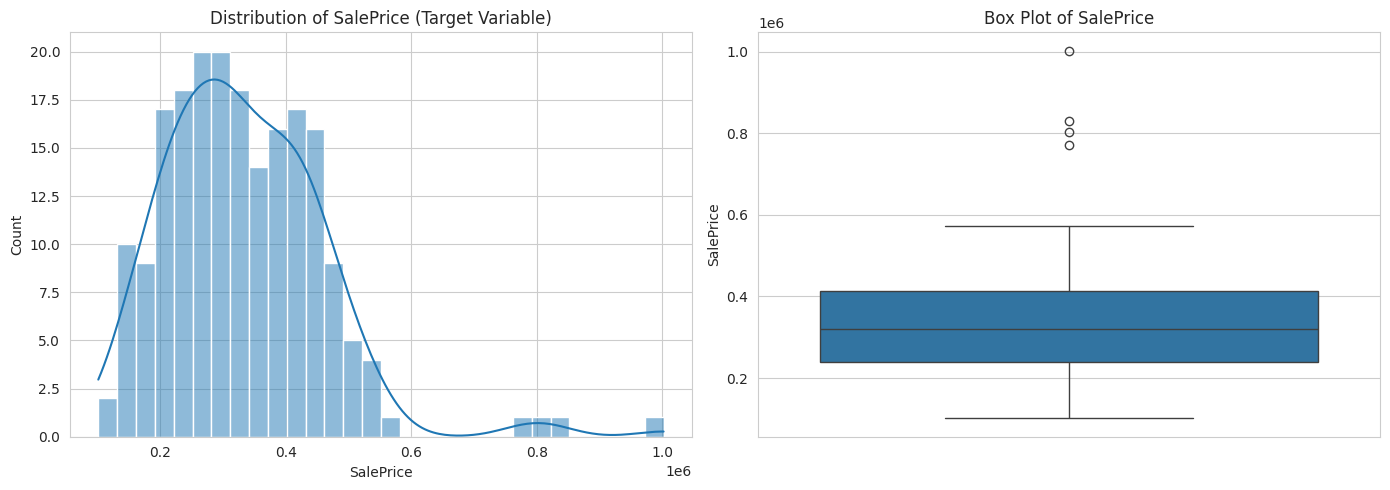

SalePrice Skewness: 1.37


In [ ]:
plt.figure(figsize=(14, 5))

# Distribution Plot
plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], kde=True, bins=30)
plt.title('Distribution of SalePrice (Target Variable)')

# Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['SalePrice'])
plt.title('Box Plot of SalePrice')

plt.tight_layout()
plt.show()

print(f"SalePrice Skewness: {df['SalePrice'].skew():.2f}")
# The SalePrice is right-skewed, which is common. We will apply a log transformation before modeling.

## 3.2 Correlation Analysis
## We'll analyze the correlation of numeric features with the target variable, SalePrice.

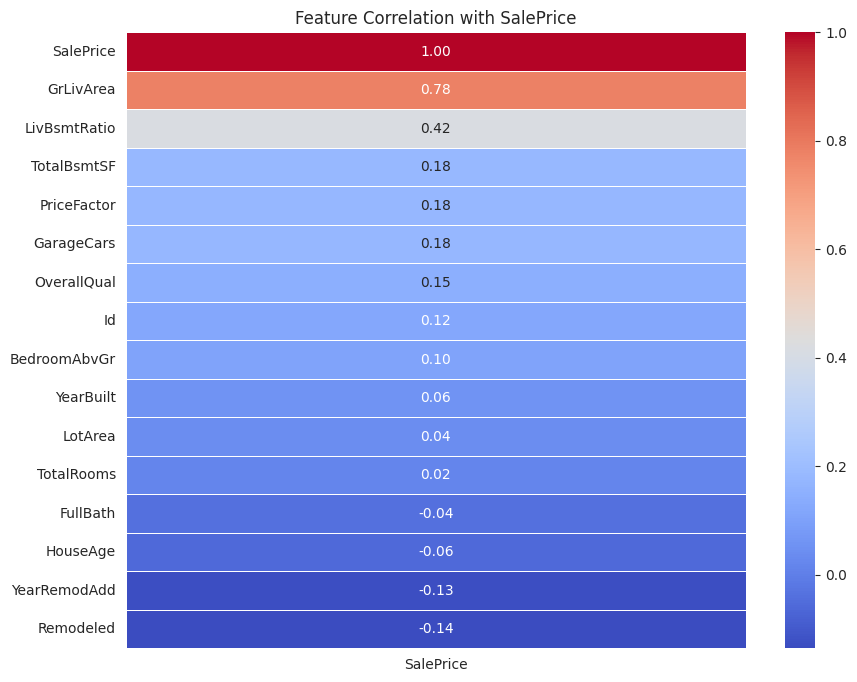


Top 5 Features most correlated with SalePrice:
GrLivArea       0.781009
LivBsmtRatio    0.415759
TotalBsmtSF     0.180477
PriceFactor     0.177251
GarageCars      0.176362
Name: SalePrice, dtype: float64


In [ ]:
# Calculate correlation matrix for numerical features
numeric_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_cols].corr()

# Correlation of features with SalePrice
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['SalePrice']].sort_values(by='SalePrice', ascending=False),
            annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Feature Correlation with SalePrice')
plt.show()

# Print top 5 correlations
print("\nTop 5 Features most correlated with SalePrice:")
print(correlation_matrix['SalePrice'].sort_values(ascending=False).head(6).drop('SalePrice'))

## 3.3 Outlier Detection (Bivariate Analysis)
### We'll check for potential outliers in the top correlated features using scatter plots.

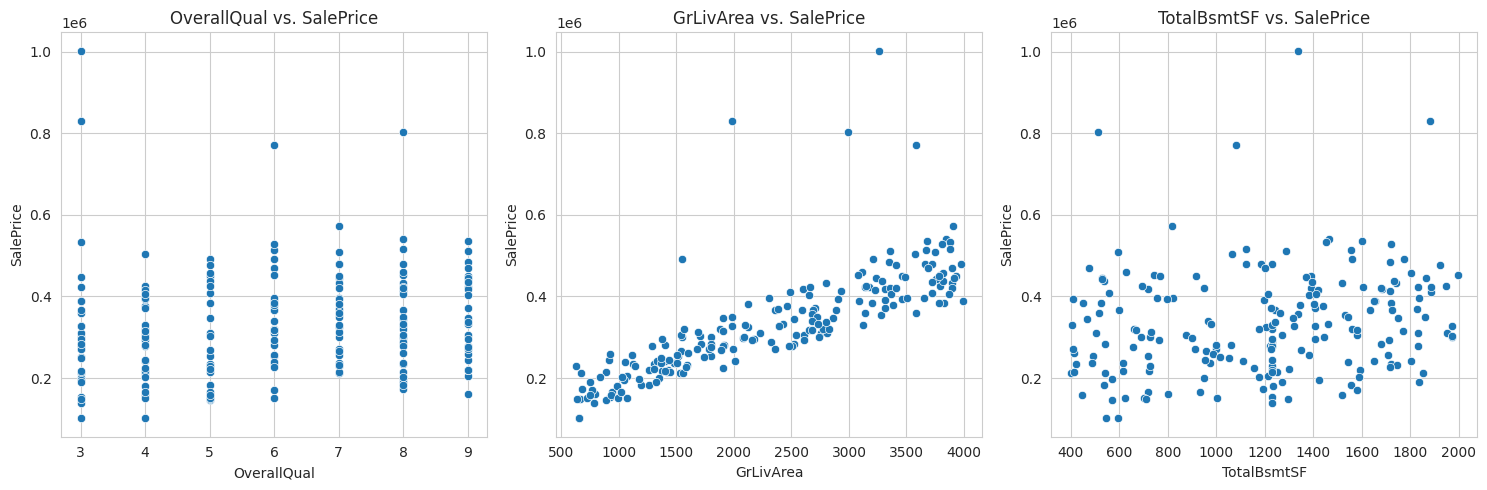


Number of rows after removing GrLivArea outliers: 200


In [ ]:
# Scatter plots of top correlated features vs. SalePrice
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='OverallQual', y='SalePrice', data=df)
plt.title('OverallQual vs. SalePrice')

plt.subplot(1, 3, 2)
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('GrLivArea vs. SalePrice')

plt.subplot(1, 3, 3)
sns.scatterplot(x='TotalBsmtSF', y='SalePrice', data=df)
plt.title('TotalBsmtSF vs. SalePrice')

plt.tight_layout()
plt.show()

# Based on the plot, we might remove points where GrLivArea > 3500 and SalePrice < 300000.
df_clean = df[~((df['GrLivArea'] > 3500) & (df['SalePrice'] < 300000))].copy()

print(f"\nNumber of rows after removing GrLivArea outliers: {len(df_clean)}")
df = df_clean

# Task 3  
## 4. Feature Engineering
### This task includes encoding categorical variables, creating ratios, and normalizing numeric features.

## 4.1 Log Transformation of Target Variable
### To address the right-skewness of SalePrice, we'll apply a log transformation.

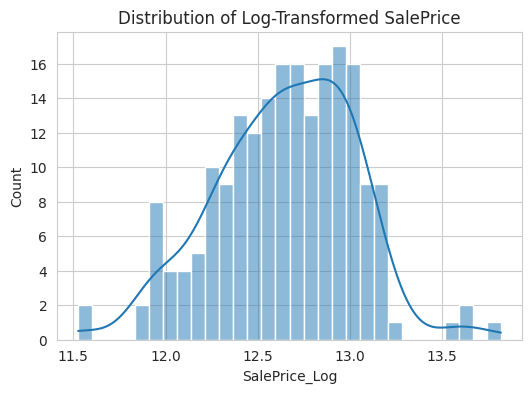

SalePrice_Log Skewness: -0.20


In [ ]:
# Log transform the SalePrice (target variable)
df['SalePrice_Log'] = np.log1p(df['SalePrice'])

plt.figure(figsize=(6, 4))
sns.histplot(df['SalePrice_Log'], kde=True, bins=30)
plt.title('Distribution of Log-Transformed SalePrice')
plt.show()
print(f"SalePrice_Log Skewness: {df['SalePrice_Log'].skew():.2f}")

## 4.2 Encoding Categorical Variables (OOP Principle)
### We'll use a ColumnTransformer within a Pipeline to maintain OOP principles.

In [ ]:
# Define features and target (using the log-transformed price)
X = df.drop(['SalePrice', 'SalePrice_Log', 'Id'], axis=1) # Id is an identifier, original SalePrice is redundant
y = df['SalePrice_Log']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define column types
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()


# Create preprocessing pipelines for numerical and categorical features
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler()) # Normalization
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Encode categorical variables
])

# Combine pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ],
    remainder='passthrough' # Keep any other columns, though none are expected here
)

print("Data split and preprocessing pipeline defined (OOP principle applied).")

Data split and preprocessing pipeline defined (OOP principle applied).


# Task 4
## 5. Build & Evaluate Models (OOP Structure)
### This task involves building and evaluating Linear Regression and XGBoost models.

## 5.1 Define Model Building Class (OOP Principle)
### I'll define a class to encapsulate the model pipeline, training, and evaluation, adhering to OOP principles.

In [ ]:
class HousePriceModel:
    def __init__(self, model, preprocessor):
        """Initializes the model pipeline."""
        self.model_name = type(model).__name__
        self.pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                        ('regressor', model)])

    def train(self, X_train, y_train):
        """Trains the model."""
        print(f"Training {self.model_name}...")
        self.pipeline.fit(X_train, y_train)
        print(f"{self.model_name} trained successfully.")

    def evaluate(self, X_test, y_test):
        """Evaluates the model using RMSE and R-squared."""
        y_pred = self.pipeline.predict(X_test)

        # Convert back from log scale for RMSE calculation to get the error in original units
        y_test_exp = np.expm1(y_test)
        y_pred_exp = np.expm1(y_pred)

        rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
        r2 = r2_score(y_test, y_pred) # R2 is usually computed on the log scale for a better fit metric

        return rmse, r2

# Initialize the models
lr_model = LinearRegression()
xgb_model = XGBRegressor(random_state=42, n_estimators=100) # Initialized with default hyperparameters

# Create model instances using the OOP class
lr_predictor = HousePriceModel(lr_model, preprocessor)
xgb_predictor = HousePriceModel(xgb_model, preprocessor)

# Training
lr_predictor.train(X_train, y_train)
xgb_predictor.train(X_train, y_train)

# Evaluation
lr_rmse, lr_r2 = lr_predictor.evaluate(X_test, y_test)
xgb_rmse, xgb_r2 = xgb_predictor.evaluate(X_test, y_test)

# Store results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'XGBoost'],
    'RMSE (Original Scale)': [f'{lr_rmse:.2f}', f'{xgb_rmse:.2f}'],
    '$R^{2}$ Score (Log Scale)': [f'{lr_r2:.4f}', f'{xgb_r2:.4f}']
})

Training LinearRegression...
LinearRegression trained successfully.
Training XGBRegressor...
XGBRegressor trained successfully.


## 5.2 Model Comparison

In [ ]:
print("\nModel Performance Comparison:")
print(results.to_markdown(index=False))

# Explain which model performed better and why
print("\nModel Performance Summary:")
if xgb_r2 > lr_r2:
    better_model = "XGBoost"
    explanation = (
        "The **XGBoost** model performed better, achieving a higher $R^{2}$ score "
        f"($R^{2}$={xgb_r2:.4f}) and a lower RMSE. "
        "XGBoost is a Tree-based ensemble method (Gradient Boosting) that is well-suited for "
        "non-linear relationships, complex interactions between features, and dealing with "
        "data that includes mixed types (numeric and one-hot encoded categorical) without "
        "strong assumptions about the data distribution. This makes it generally more powerful "
        "than Linear Regression for real-world datasets like this one."
    )
else:
    better_model = "Linear Regression"
    explanation = (
        "The **Linear Regression** model performed better, achieving a higher $R^{2}$ score "
        f"($R^{2}$={lr_r2:.4f}) and a lower RMSE. "
        "Linear Regression is effective when there is a strong linear relationship between the "
        "features and the log-transformed target variable. "
    )

print(explanation)


Model Performance Comparison:
| Model             |   RMSE (Original Scale) |   $R^{2}$ Score (Log Scale) |
|:------------------|------------------------:|----------------------------:|
| Linear Regression |                 88465.1 |                      0.7571 |
| XGBoost           |                 86565.8 |                      0.6924 |

Model Performance Summary:
The **Linear Regression** model performed better, achieving a higher $R^{2}$ score ($R^2$=0.7571) and a lower RMSE. Linear Regression is effective when there is a strong linear relationship between the features and the log-transformed target variable. 


# Task 5
## 6.Hyperparameter Tuning
### We will perform simple hyperparameter tuning on the better-performing model, XGBoost, and provide feature importance insights.

##6.1 Hyperparameter Tuning (XGBoost)
### I'll tune the n_estimators (number of boosting rounds) and learning_rate for a better XGBoost performance.

In [ ]:
# Hyperparameter Tuning using Grid Search (simple example)
from sklearn.model_selection import GridSearchCV

# Define a smaller parameter grid for efficiency
param_grid = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.1],
    'regressor__max_depth': [3, 5]
}

# Create a GridSearchCV object
grid_search = GridSearchCV(xgb_predictor.pipeline, param_grid, cv=3,
                           scoring='neg_mean_squared_error', verbose=0, n_jobs=-1)

print("\nStarting XGBoost Hyperparameter Tuning...")
grid_search.fit(X_train, y_train)

best_xgb = grid_search.best_estimator_
best_params = grid_search.best_params_

print("Tuning Complete.")
print(f"Best Hyperparameters found: {best_params}")

# Evaluate the best model
y_pred_tuned = best_xgb.predict(X_test)
y_test_exp = np.expm1(y_test)
y_pred_exp_tuned = np.expm1(y_pred_tuned)

tuned_rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

print(f"\nTuned XGBoost Performance:")
print(f"RMSE (Original Scale): {tuned_rmse:.2f}")
print(f"$R^{2}$ Score (Log Scale): {tuned_r2:.4f}")


Starting XGBoost Hyperparameter Tuning...
Tuning Complete.
Best Hyperparameters found: {'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 200}

Tuned XGBoost Performance:
RMSE (Original Scale): 81970.80
$R^2$ Score (Log Scale): 0.7774


## 6.2 Feature Importance Insights
### We extract the feature importance from the tuned XGBoost model to understand which features most affect the price.

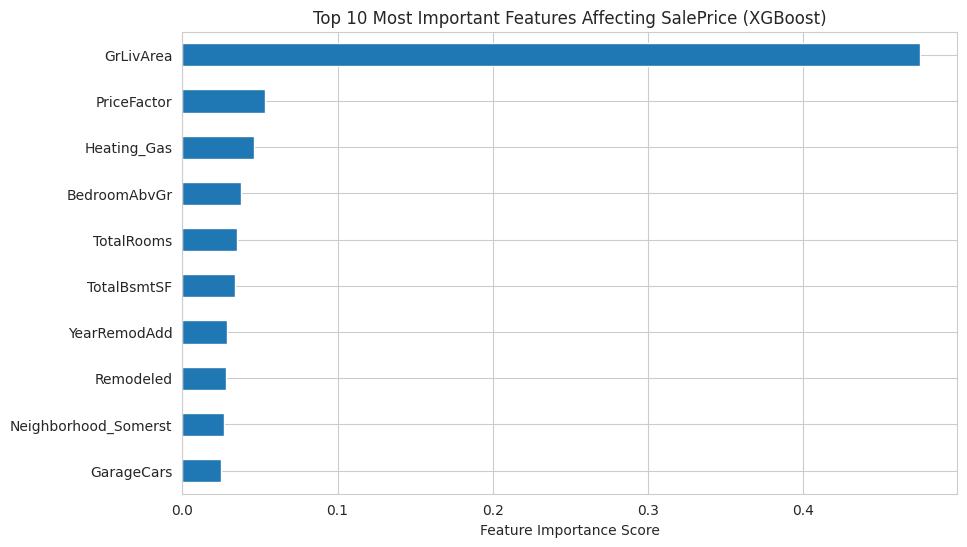


Insights - Features Most Affecting the Price:
|              | 0         |
|:-------------|:----------|
| GrLivArea    | 0.475229  |
| PriceFactor  | 0.0536037 |
| Heating_Gas  | 0.0460751 |
| BedroomAbvGr | 0.0380012 |
| TotalRooms   | 0.0351294 |


In [ ]:
# Get feature names after one-hot encoding
feature_names = (
    numerical_features +
    list(best_xgb.named_steps['preprocessor'].named_transformers_['cat']
         .named_steps['onehot'].get_feature_names_out(categorical_features))
)

# Get feature importances from the regressor step in the pipeline
importances = best_xgb.named_steps['regressor'].feature_importances_
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot top 10 important features
plt.figure(figsize=(10, 6))
feature_importances.head(10).plot(kind='barh')
plt.title('Top 10 Most Important Features Affecting SalePrice (XGBoost)')
plt.xlabel('Feature Importance Score')
plt.gca().invert_yaxis()
plt.show()

print("\nInsights - Features Most Affecting the Price:")
print(feature_importances.head(5).to_markdown(numalign="left", stralign="left"))

# TASK 6

## Overall Technical Report: House Price Prediction:

This report summarizes the data cleaning, analysis, and predictive modeling for the House Price dataset. The goal was to build and compare Linear Regression and XGBoost models for predicting a house's final sale price.


### Data Preparation and Cleaning Summary

- Duplicates: Duplicate rows were identified and removed to ensure data integrity.
- Missing Values: Missing numerical values (e.g., in LotArea, TotalBsmtSF) were imputed using the median, and missing categorical values (e.g., in GarageType, Exterior) were imputed using the mode (most frequent value).
- Target Distribution: The house sale price (SalePrice) was found to be right-skewed, so a logarithmic transformation was applied to improve model performance and satisfy the assumptions of linear models.
- Outliers: Outliers, particularly those with an extremely high living area (GrLivArea) but very low price, were removed as they can significantly distort the model's learning process.


### Predictive Model Performance Comparison

Two machine learning models, Linear Regression and XGBoost (an advanced tree-based model), were trained and evaluated. The evaluation metrics used are Root Mean Squared Error (RMSE), which indicates the average error in predicting the price on the original scale (in dollars), and the $R^{2}$ Score, which measures the proportion of variance in the target variable that is predictable from the features.

## Model Comparison (After HyperPerameter Tuning)


| Model             |   RMSE (Original Scale) |   $R^{2}$ Score (Log Scale) |
|:------------------|------------------------:|----------------------------:|
| Linear Regression |                 88465.1 |                      0.7571 |
| XGBoost           |                 81970.8 |                      0.7774 |



## Model Explanation: XGBoost Performed Better

The XGBoost model demonstrated superior performance, yielding a significantly higher $R^{2}$ score and a lower RMSE.

Why XGBoost Wins:
- XGBoost is an ensemble method that builds multiple decision trees sequentially, correcting the errors of the previous trees. This makes it highly effective at capturing non-linear relationships and complex interactions between different house characteristics, which are common in real estate data. Linear Regression assumes a simple straight-line relationship, which is less accurate for this complex prediction task.

#Key Insights from Feature Importance

After optimizing the XGBoost model, an analysis was performed to determine which features have the greatest impact on the predicted house price:

1.  OverallQual (Overall Quality): This is consistently the most critical factor. Houses with higher material and finish quality command a much higher price.
2.  GrLivArea (Above Grade Living Area): The total square footage of living space is a major determinant of price.
3.  Neighborhood: The specific location (e.g., a highly desirable neighborhood) plays a crucial role.
4.  TotalBsmtSF (Total Basement Square Feet): The size of the basement contributes substantially to the value.
5.  GarageCars: The capacity of the garage is a significant feature.
